# Task 4 — Channel Trend-Following Strategy Implementation

This notebook implements the **Channel WithDDControl** trend-following strategy for
the primary market, **CBOT Soybeans (SY)**.

The strategy combines:

- rolling highest-high / lowest-low breakout signals;
- long and short futures positions;
- percentage-based trailing-stop risk control;
- contract-specific point value and transaction costs;
- mark-to-market equity accounting.

The objective of this notebook is to build a **reusable and validated strategy engine**.
The same trading logic will later be used for walk-forward optimization, full-sample
optimization, and sensitivity analysis so that performance comparisons are based on
a consistent backtesting framework.

The cleaned SY dataset produced in **Task 2** is used directly. This ensures that the
statistical analysis in Task 3 and the strategy analysis here are based on the same
validated 5-minute price history.

## 0. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from itertools import product
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', '{:,.2f}'.format)


## 1. Load Validated SY Data

In [2]:
DATA = Path('data')
CLEAN = DATA / 'clean'

SY_PATH = CLEAN / 'SY.parquet'

if not SY_PATH.exists():
    raise FileNotFoundError(
        f'{SY_PATH} not found. Please run Task 2 first.'
    )

sy = pd.read_parquet(SY_PATH).copy()
sy['ts'] = pd.to_datetime(sy['ts'])

required_cols = ['ts', 'Open', 'High', 'Low', 'Close']
missing_cols = [col for col in required_cols if col not in sy.columns]

if missing_cols:
    raise ValueError(
        f'SY cleaned dataset is missing required columns: {missing_cols}'
    )

sy = (
    sy.sort_values('ts')
      .drop_duplicates(subset='ts', keep='last')
      .reset_index(drop=True)
)

print(
    f'SY: {len(sy):,} rows | '
    f'{sy["ts"].min()} → {sy["ts"].max()}'
)

SY: 495,740 rows | 1982-07-01 09:35:00 → 2026-04-10 13:15:00


## 2. Demonstration Configuration

Before parameter optimization, the strategy engine is tested on a recent two-year
subset of SY data using a fixed parameter pair.

This subset is used **only for implementation validation and illustration**. It is
not used to select the final strategy parameters or to evaluate out-of-sample
performance.

The formal parameter search and walk-forward evaluation are performed in the
subsequent optimization tasks.

In [3]:
# Fixed parameters used only to validate the strategy engine
CHN_LEN = 2000
STP_PCT = 0.02

# SY contract economics
PV = 50.0
SLPG = 35.5
INITIAL_EQUITY = 100_000.0

# Demonstration evaluation period
DEMO_YEARS = 2

demo_start = sy['ts'].max() - pd.DateOffset(years=DEMO_YEARS)

# Locate the first bar of the evaluation period
demo_start_idx = sy['ts'].searchsorted(demo_start)

# Retain enough prior observations to construct the channel
warmup_start_idx = max(
    0,
    demo_start_idx - CHN_LEN
)

df = (
    sy.iloc[warmup_start_idx:]
      .copy()
      .reset_index(drop=True)
)

# Timestamp from which performance should actually be evaluated
EVAL_START = sy.iloc[demo_start_idx]['ts']

print(
    f'Engine input: {len(df):,} bars | '
    f'{df["ts"].min()} → {df["ts"].max()}'
)

print(
    f'Demonstration evaluation period: '
    f'{EVAL_START} → {df["ts"].max()}'
)

print(
    f'Warm-up bars supplied: '
    f'{demo_start_idx - warmup_start_idx:,}'
)

print(
    f'Parameters: ChnLen={CHN_LEN:,}, '
    f'StpPct={STP_PCT:.2%}, '
    f'PV=${PV:g}, '
    f'Slpg=${SLPG:.2f}'
)

Engine input: 24,523 bars | 2024-02-06 11:35:00 → 2026-04-10 13:15:00
Demonstration evaluation period: 2024-04-10 13:15:00 → 2026-04-10 13:15:00
Warm-up bars supplied: 2,000
Parameters: ChnLen=2,000, StpPct=2.00%, PV=$50, Slpg=$35.50


## 3. Strategy Engine

The strategy follows a channel-breakout framework with percentage-based trailing-stop
control.

For each bar, the upper and lower channel boundaries are computed using only the
**previous `ChnLen` bars**. The current bar is excluded from the channel calculation
to prevent look-ahead bias.

Trading therefore begins only after a complete channel history is available.
Transaction costs are incorporated explicitly when positions are entered, exited,
or reversed.

In [4]:
def backtest_tf_channel_stop(
    df,
    chn_len,
    stp_pct,
    slpg,
    pv,
    init_capital
):
    """
    Run the Channel WithDDControl strategy.

    The bar-by-bar trading logic follows the professor's main.m:

    - HH / LL use only the previous chn_len bars.
    - Flat -> long/short entries use half round-turn slippage.
    - Trailing-stop exits use half round-turn slippage.
    - Direct long/short reversals use full round-turn slippage.
    - If both channel boundaries are crossed while flat, the
      professor's same-bar accounting rule is applied and the
      strategy remains flat.
    - Trailing-stop benchmarks are updated after the current
      bar's trading decision.

    Parameters
    ----------
    df : pd.DataFrame
        Cleaned OHLC data with columns:
        ts, Open, High, Low, Close.

    chn_len : int
        Number of prior bars used for the breakout channel.

    stp_pct : float
        Percentage trailing-stop distance.

    slpg : float
        Full round-turn transaction cost.

    pv : float
        Point value of the futures contract.

    init_capital : float
        Initial strategy equity.

    Returns
    -------
    result : pd.DataFrame
        Bar-level backtest results including channel levels,
        position, P&L, equity, drawdown, and trading activity.

    events : pd.DataFrame
        Event-level trading log.
    """

    # 1. Input validation

    required_cols = ['ts', 'Open', 'High', 'Low', 'Close']

    missing_cols = [
        col for col in required_cols
        if col not in df.columns
    ]

    if missing_cols:
        raise ValueError(
            f'Missing required columns: {missing_cols}'
        )

    if chn_len <= 0:
        raise ValueError('chn_len must be positive.')

    if not 0 < stp_pct < 1:
        raise ValueError('stp_pct must lie between 0 and 1.')

    if slpg < 0:
        raise ValueError('slpg cannot be negative.')

    if pv <= 0:
        raise ValueError('pv must be positive.')

    data = (
        df.copy()
          .sort_values('ts')
          .reset_index(drop=True)
    )

    data['ts'] = pd.to_datetime(data['ts'])

    n = len(data)

    if n <= chn_len:
        raise ValueError(
            f'Not enough observations ({n:,}) '
            f'for ChnLen={chn_len:,}.'
        )

    # 2. Breakout channel
    # shift(1) ensures that the current bar is NOT included in
    # its own breakout channel.

    data['HH'] = (
        data['High']
        .rolling(
            window=chn_len,
            min_periods=chn_len
        )
        .max()
        .shift(1)
    )

    data['LL'] = (
        data['Low']
        .rolling(
            window=chn_len,
            min_periods=chn_len
        )
        .min()
        .shift(1)
    )

    # 3. Backtest arrays and state

    equity = np.full(n, init_capital, dtype=float)
    bar_pnl = np.zeros(n, dtype=float)
    drawdown = np.zeros(n, dtype=float)

    position_series = np.zeros(n, dtype=int)
    trade_units = np.zeros(n, dtype=float)

    position = 0
    equity_max = init_capital

    benchmark_long = np.nan
    benchmark_short = np.nan

    events = []

    # 4. Bar-by-bar strategy simulation

    for i in range(chn_len, n):

        prev = data.iloc[i - 1]
        curr = data.iloc[i]

        position_before = position

        # Mark-to-market P&L from the position carried
        # into the current bar.
        delta = (
            pv
            * (curr['Close'] - prev['Close'])
            * position
        )

        traded = False
        action = None
        execution_price = np.nan

        # ========================================================
        # A. FLAT POSITION
        # ========================================================

        if position == 0:

            buy_signal = curr['High'] >= curr['HH']
            sell_signal = curr['Low'] <= curr['LL']

            # Both channel boundaries crossed in the same bar.
            # Intrabar ordering is unknown.
            # Follow professor's original same-bar rule.
            if buy_signal and sell_signal:

                delta = (
                    -slpg
                    + pv * (curr['LL'] - curr['HH'])
                )

                trade_units[i] = 1.0

                action = 'both_channels_same_bar'

                events.append({
                    'ts': curr['ts'],
                    'action': action,
                    'position_before': 0,
                    'position_after': 0,
                    'price': np.nan,
                    'bar_pnl': delta,
                    'trade_units': 1.0
                })

            elif buy_signal:

                # Flat -> long
                delta = (
                    -slpg / 2
                    + pv * (curr['Close'] - curr['HH'])
                )

                position = 1
                traded = True

                benchmark_long = curr['High']
                benchmark_short = np.nan

                execution_price = curr['HH']
                trade_units[i] = 0.5

                action = 'enter_long'

                events.append({
                    'ts': curr['ts'],
                    'action': action,
                    'position_before': 0,
                    'position_after': 1,
                    'price': execution_price,
                    'bar_pnl': delta,
                    'trade_units': 0.5
                })

            elif sell_signal:

                # Flat -> short
                delta = (
                    -slpg / 2
                    - pv * (curr['Close'] - curr['LL'])
                )

                position = -1
                traded = True

                benchmark_short = curr['Low']
                benchmark_long = np.nan

                execution_price = curr['LL']
                trade_units[i] = 0.5

                action = 'enter_short'

                events.append({
                    'ts': curr['ts'],
                    'action': action,
                    'position_before': 0,
                    'position_after': -1,
                    'price': execution_price,
                    'bar_pnl': delta,
                    'trade_units': 0.5
                })

        # ========================================================
        # B. LONG POSITION
        # ========================================================

        if position == 1 and not traded:

            channel_reverse = (
                curr['Low'] <= curr['LL']
            )

            stop_price = (
                benchmark_long
                * (1 - stp_pct)
            )

            stop_trigger = (
                curr['Low'] <= stop_price
            )

            # If channel reversal and stop occur together,
            # professor's code gives priority to reversal.
            if channel_reverse and stop_trigger:

                delta = (
                    delta
                    - slpg
                    - 2 * pv * (
                        curr['Close'] - curr['LL']
                    )
                )

                position = -1
                benchmark_short = curr['Low']

                execution_price = curr['LL']
                trade_units[i] = 1.0

                action = 'reverse_long_to_short'

                events.append({
                    'ts': curr['ts'],
                    'action': action,
                    'position_before': 1,
                    'position_after': -1,
                    'price': execution_price,
                    'bar_pnl': delta,
                    'trade_units': 1.0
                })

            else:

                if stop_trigger:

                    delta = (
                        delta
                        - slpg / 2
                        - pv * (
                            curr['Close']
                            - stop_price
                        )
                    )

                    position = 0

                    execution_price = stop_price
                    trade_units[i] = 0.5

                    action = 'stop_exit_long'

                    events.append({
                        'ts': curr['ts'],
                        'action': action,
                        'position_before': 1,
                        'position_after': 0,
                        'price': execution_price,
                        'bar_pnl': delta,
                        'trade_units': 0.5
                    })

                if channel_reverse:

                    delta = (
                        delta
                        - slpg
                        - 2 * pv * (
                            curr['Close'] - curr['LL']
                        )
                    )

                    position = -1
                    benchmark_short = curr['Low']

                    execution_price = curr['LL']
                    trade_units[i] = 1.0

                    action = 'reverse_long_to_short'

                    events.append({
                        'ts': curr['ts'],
                        'action': action,
                        'position_before': 1,
                        'position_after': -1,
                        'price': execution_price,
                        'bar_pnl': delta,
                        'trade_units': 1.0
                    })

            # Important:
            # update long benchmark only AFTER current-bar decisions.
            benchmark_long = max(
                curr['High'],
                benchmark_long
            )

        # ========================================================
        # C. SHORT POSITION
        # ========================================================

        if position == -1 and not traded:

            channel_reverse = (
                curr['High'] >= curr['HH']
            )

            stop_price = (
                benchmark_short
                * (1 + stp_pct)
            )

            stop_trigger = (
                curr['High'] >= stop_price
            )

            # If channel reversal and stop occur together,
            # professor's code gives priority to reversal.
            if channel_reverse and stop_trigger:

                delta = (
                    delta
                    - slpg
                    + 2 * pv * (
                        curr['Close'] - curr['HH']
                    )
                )

                position = 1
                benchmark_long = curr['High']

                execution_price = curr['HH']
                trade_units[i] = 1.0

                action = 'reverse_short_to_long'

                events.append({
                    'ts': curr['ts'],
                    'action': action,
                    'position_before': -1,
                    'position_after': 1,
                    'price': execution_price,
                    'bar_pnl': delta,
                    'trade_units': 1.0
                })

            else:

                if stop_trigger:

                    delta = (
                        delta
                        - slpg / 2
                        + pv * (
                            curr['Close']
                            - stop_price
                        )
                    )

                    position = 0

                    execution_price = stop_price
                    trade_units[i] = 0.5

                    action = 'stop_exit_short'

                    events.append({
                        'ts': curr['ts'],
                        'action': action,
                        'position_before': -1,
                        'position_after': 0,
                        'price': execution_price,
                        'bar_pnl': delta,
                        'trade_units': 0.5
                    })

                if channel_reverse:

                    delta = (
                        delta
                        - slpg
                        + 2 * pv * (
                            curr['Close'] - curr['HH']
                        )
                    )

                    position = 1
                    benchmark_long = curr['High']

                    execution_price = curr['HH']
                    trade_units[i] = 1.0

                    action = 'reverse_short_to_long'

                    events.append({
                        'ts': curr['ts'],
                        'action': action,
                        'position_before': -1,
                        'position_after': 1,
                        'price': execution_price,
                        'bar_pnl': delta,
                        'trade_units': 1.0
                    })

            # Update short benchmark after current-bar decisions.
            benchmark_short = min(
                curr['Low'],
                benchmark_short
            )

        # 5. Equity and drawdown

        bar_pnl[i] = delta

        equity[i] = (
            equity[i - 1]
            + delta
        )

        equity_max = max(
            equity_max,
            equity[i]
        )

        drawdown[i] = (
            equity[i]
            - equity_max
        )

        position_series[i] = position

    # Carry the initial flat position through the warm-up period.
    position_series[:chn_len] = 0

    # 6. Build result tables

    result = data[
        [
            'ts',
            'Open',
            'High',
            'Low',
            'Close',
            'HH',
            'LL'
        ]
    ].copy()

    result['position'] = position_series
    result['bar_pnl'] = bar_pnl
    result['equity'] = equity
    result['drawdown'] = drawdown
    result['trade_units'] = trade_units

    events = pd.DataFrame(
        events,
        columns=[
            'ts',
            'action',
            'position_before',
            'position_after',
            'price',
            'bar_pnl',
            'trade_units'
        ]
    )

    return result, events

In [5]:
result, events = backtest_tf_channel_stop(
    df=df,
    chn_len=CHN_LEN,
    stp_pct=STP_PCT,
    slpg=SLPG,
    pv=PV,
    init_capital=INITIAL_EQUITY
)

print(
    f'Backtest complete | '
    f'{len(result):,} bars | '
    f'{len(events):,} trade events'
)

print(
    f'Final equity: ${result["equity"].iloc[-1]:,.2f}'
)

print(
    f'Max drawdown: ${result["drawdown"].min():,.2f}'
)

events.head(10)

Backtest complete | 24,523 bars | 52 trade events
Final equity: $102,813.50
Max drawdown: $-8,432.00


,ts,action,position_before,position_after,price,bar_pnl,trade_units
0,2024-05-03 12:45:00,enter_long,0,1,"1,214.50",-105.25,0.50
1,2024-05-08 12:15:00,stop_exit_long,1,0,"1,231.37",-36.75,0.50
2,2024-06-26 09:35:00,enter_short,0,-1,"1,155.00",319.75,0.50
3,2024-07-02 09:35:00,stop_exit_short,-1,0,"1,153.11",-373.25,0.50
4,2024-07-09 11:50:00,enter_short,0,-1,"1,130.50",44.75,0.50
5,2024-07-17 09:35:00,stop_exit_short,-1,0,"1,098.54",-432.25,0.50
6,2024-07-26 13:15:00,enter_short,0,-1,"1,077.00",-5.25,0.50
7,2024-07-29 11:45:00,stop_exit_short,-1,0,"1,028.67",-76.25,0.50
8,2024-07-31 09:55:00,enter_short,0,-1,"1,008.50",107.25,0.50
9,2024-08-05 09:45:00,stop_exit_short,-1,0,"1,025.36",-285.50,0.50


In [6]:
# Restrict reported performance to the intended demonstration period
demo_result = (
    result.loc[result['ts'] >= EVAL_START]
          .copy()
          .reset_index(drop=True)
)

demo_events = (
    events.loc[events['ts'] >= EVAL_START]
          .copy()
          .reset_index(drop=True)
)

print(
    f'Evaluation sample: {len(demo_result):,} bars | '
    f'{demo_result["ts"].min()} → {demo_result["ts"].max()}'
)

print(
    f'Trade events during evaluation: {len(demo_events):,}'
)

Evaluation sample: 22,523 bars | 2024-04-10 13:15:00 → 2026-04-10 13:15:00
Trade events during evaluation: 52


## 4. Backtest Validation

Before interpreting strategy performance, the implementation is subjected to a set
of internal consistency checks.

The validation focuses on four properties:

- the breakout channel uses only information available before the current bar;
- the warm-up period contains no trading activity;
- cumulative bar-level P&L reconciles exactly with the equity curve;
- reported drawdown is consistent with the running equity maximum.

These checks are intended to detect common backtesting errors such as look-ahead
bias, incorrect initialization, and inconsistent P&L accounting.

In [8]:
# Backtest validation checks

tol = 1e-8

# 1. Channel timing:
# first valid channel must appear exactly after chn_len prior bars
first_valid_hh = result['HH'].first_valid_index()
first_valid_ll = result['LL'].first_valid_index()

channel_timing_ok = (
    first_valid_hh == CHN_LEN
    and first_valid_ll == CHN_LEN
)

# 2. Warm-up period must contain no trading activity
warmup_trade_units = result.loc[
    result['ts'] < EVAL_START,
    'trade_units'
].sum()

warmup_ok = np.isclose(
    warmup_trade_units,
    0.0,
    atol=tol
)

# 3. Equity must reconcile with cumulative bar P&L
equity_reconstructed = (
    INITIAL_EQUITY
    + result['bar_pnl'].cumsum()
)

equity_error = np.max(
    np.abs(
        result['equity'].to_numpy()
        - equity_reconstructed.to_numpy()
    )
)

equity_ok = equity_error < tol

# 4. Drawdown must equal equity minus running maximum
expected_drawdown = (
    result['equity']
    - result['equity'].cummax()
)

drawdown_error = np.max(
    np.abs(
        result['drawdown'].to_numpy()
        - expected_drawdown.to_numpy()
    )
)

drawdown_ok = drawdown_error < tol

validation = pd.DataFrame({
    'Check': [
        'Channel uses prior bars only',
        'No trades during warm-up',
        'Equity reconciles with bar P&L',
        'Drawdown reconciles with running peak'
    ],
    'Passed': [
        channel_timing_ok,
        warmup_ok,
        equity_ok,
        drawdown_ok
    ],
    'Diagnostic': [
        f'First valid channel index = {first_valid_hh}',
        f'Warm-up trade units = {warmup_trade_units:.2f}',
        f'Max equity error = {equity_error:.10f}',
        f'Max drawdown error = {drawdown_error:.10f}'
    ]
})

validation

,Check,Passed,Diagnostic
0,Channel uses prior bars only,True,First valid channel index = 2000
1,No trades during warm-up,True,Warm-up trade units = 0.00
2,Equity reconciles with bar P&L,True,Max equity error = 0.0000000000
3,Drawdown reconciles with running peak,True,Max drawdown error = 0.0000000000


## 5. Round-Trip Trade Ledger

The event log records individual executions such as entries, stop exits, and
position reversals. For trade-level performance analysis, these events are paired
into complete round-trip trades.

Each completed trade records its entry and exit timestamps, direction, execution
prices, holding period, gross P&L, transaction cost, and net P&L.

For accounting purposes, half of the round-turn transaction cost is assigned to
each side of a trade. A direct reversal therefore closes the existing trade and
simultaneously opens the next trade, with one-half of the reversal cost allocated
to each position.

In [9]:
def build_round_trip_ledger(
    events,
    result,
    pv,
    slpg
):
    """
    Convert the event-level execution log into completed round-trip trades.

    Reversal events simultaneously:
    1. close the existing position, and
    2. open a new position in the opposite direction.

    Half of the round-turn transaction cost is allocated to each
    side of every trade.
    """

    # Map timestamps to bar indices so that holding period can be measured
    bar_index = pd.Series(
        result.index.to_numpy(),
        index=pd.to_datetime(result['ts'])
    ).to_dict()

    trades = []
    open_trade = None
    same_bar_events = []

    for _, event in events.iterrows():

        ts = pd.Timestamp(event['ts'])
        action = event['action']
        price = event['price']

        # --------------------------------------------------------
        # Same-bar double-channel event:
        # no position is carried forward
        # --------------------------------------------------------
        if action == 'both_channels_same_bar':

            same_bar_events.append({
                'ts': ts,
                'action': action,
                'net_pnl': event['bar_pnl']
            })

            continue

        # --------------------------------------------------------
        # Flat -> Long
        # --------------------------------------------------------
        if action == 'enter_long':

            open_trade = {
                'entry_time': ts,
                'direction': 1,
                'direction_label': 'Long',
                'entry_price': price,
                'entry_bar': bar_index.get(ts, np.nan),
                'entry_cost': slpg / 2
            }

        # --------------------------------------------------------
        # Flat -> Short
        # --------------------------------------------------------
        elif action == 'enter_short':

            open_trade = {
                'entry_time': ts,
                'direction': -1,
                'direction_label': 'Short',
                'entry_price': price,
                'entry_bar': bar_index.get(ts, np.nan),
                'entry_cost': slpg / 2
            }

        # --------------------------------------------------------
        # Long stop exit
        # --------------------------------------------------------
        elif action == 'stop_exit_long':

            if open_trade is None or open_trade['direction'] != 1:
                raise RuntimeError(
                    f'Invalid long exit at {ts}: no open long trade.'
                )

            exit_bar = bar_index.get(ts, np.nan)

            gross_pnl = (
                pv
                * (price - open_trade['entry_price'])
            )

            total_cost = (
                open_trade['entry_cost']
                + slpg / 2
            )

            net_pnl = gross_pnl - total_cost

            trades.append({
                'entry_time': open_trade['entry_time'],
                'exit_time': ts,
                'direction': 'Long',
                'entry_price': open_trade['entry_price'],
                'exit_price': price,
                'holding_bars': (
                    exit_bar - open_trade['entry_bar']
                ),
                'gross_pnl': gross_pnl,
                'transaction_cost': total_cost,
                'net_pnl': net_pnl,
                'exit_reason': 'Trailing stop'
            })

            open_trade = None

        # --------------------------------------------------------
        # Short stop exit
        # --------------------------------------------------------
        elif action == 'stop_exit_short':

            if open_trade is None or open_trade['direction'] != -1:
                raise RuntimeError(
                    f'Invalid short exit at {ts}: no open short trade.'
                )

            exit_bar = bar_index.get(ts, np.nan)

            gross_pnl = (
                pv
                * (open_trade['entry_price'] - price)
            )

            total_cost = (
                open_trade['entry_cost']
                + slpg / 2
            )

            net_pnl = gross_pnl - total_cost

            trades.append({
                'entry_time': open_trade['entry_time'],
                'exit_time': ts,
                'direction': 'Short',
                'entry_price': open_trade['entry_price'],
                'exit_price': price,
                'holding_bars': (
                    exit_bar - open_trade['entry_bar']
                ),
                'gross_pnl': gross_pnl,
                'transaction_cost': total_cost,
                'net_pnl': net_pnl,
                'exit_reason': 'Trailing stop'
            })

            open_trade = None

        # --------------------------------------------------------
        # Long -> Short reversal
        # --------------------------------------------------------
        elif action == 'reverse_long_to_short':

            if open_trade is None or open_trade['direction'] != 1:
                raise RuntimeError(
                    f'Invalid long-to-short reversal at {ts}.'
                )

            exit_bar = bar_index.get(ts, np.nan)

            gross_pnl = (
                pv
                * (price - open_trade['entry_price'])
            )

            total_cost = (
                open_trade['entry_cost']
                + slpg / 2
            )

            net_pnl = gross_pnl - total_cost

            trades.append({
                'entry_time': open_trade['entry_time'],
                'exit_time': ts,
                'direction': 'Long',
                'entry_price': open_trade['entry_price'],
                'exit_price': price,
                'holding_bars': (
                    exit_bar - open_trade['entry_bar']
                ),
                'gross_pnl': gross_pnl,
                'transaction_cost': total_cost,
                'net_pnl': net_pnl,
                'exit_reason': 'Channel reversal'
            })

            # Same reversal immediately opens a new short.
            open_trade = {
                'entry_time': ts,
                'direction': -1,
                'direction_label': 'Short',
                'entry_price': price,
                'entry_bar': exit_bar,
                'entry_cost': slpg / 2
            }

        # --------------------------------------------------------
        # Short -> Long reversal
        # --------------------------------------------------------
        elif action == 'reverse_short_to_long':

            if open_trade is None or open_trade['direction'] != -1:
                raise RuntimeError(
                    f'Invalid short-to-long reversal at {ts}.'
                )

            exit_bar = bar_index.get(ts, np.nan)

            gross_pnl = (
                pv
                * (open_trade['entry_price'] - price)
            )

            total_cost = (
                open_trade['entry_cost']
                + slpg / 2
            )

            net_pnl = gross_pnl - total_cost

            trades.append({
                'entry_time': open_trade['entry_time'],
                'exit_time': ts,
                'direction': 'Short',
                'entry_price': open_trade['entry_price'],
                'exit_price': price,
                'holding_bars': (
                    exit_bar - open_trade['entry_bar']
                ),
                'gross_pnl': gross_pnl,
                'transaction_cost': total_cost,
                'net_pnl': net_pnl,
                'exit_reason': 'Channel reversal'
            })

            # Same reversal immediately opens a new long.
            open_trade = {
                'entry_time': ts,
                'direction': 1,
                'direction_label': 'Long',
                'entry_price': price,
                'entry_bar': exit_bar,
                'entry_cost': slpg / 2
            }

    trade_ledger = pd.DataFrame(trades)

    same_bar_events = pd.DataFrame(
        same_bar_events,
        columns=['ts', 'action', 'net_pnl']
    )

    return trade_ledger, same_bar_events, open_trade

In [10]:
trade_ledger, same_bar_events, open_trade = build_round_trip_ledger(
    events=demo_events,
    result=result,
    pv=PV,
    slpg=SLPG
)

print(f'Completed round-trip trades: {len(trade_ledger)}')
print(f'Same-bar double-channel events: {len(same_bar_events)}')

if open_trade is None:
    print('Open position at sample end: None')
else:
    print(
        'Open position at sample end: '
        f'{open_trade["direction_label"]} | '
        f'Entry {open_trade["entry_time"]} @ '
        f'{open_trade["entry_price"]:,.2f}'
    )

trade_ledger.head(10)

Completed round-trip trades: 26
Same-bar double-channel events: 0
Open position at sample end: None


,entry_time,exit_time,direction,entry_price,exit_price,holding_bars,gross_pnl,transaction_cost,net_pnl,exit_reason
0,2024-05-03 12:45:00,2024-05-08 12:15:00,Long,"1,214.50","1,231.37",129,843.50,35.50,808.00,Trailing stop
1,2024-06-26 09:35:00,2024-07-02 09:35:00,Short,"1,155.00","1,153.11",180,94.50,35.50,59.00,Trailing stop
2,2024-07-09 11:50:00,2024-07-17 09:35:00,Short,"1,130.50","1,098.54",243,"1,598.00",35.50,"1,562.50",Trailing stop
3,2024-07-26 13:15:00,2024-07-29 11:45:00,Short,"1,077.00","1,028.67",27,"2,416.50",35.50,"2,381.00",Trailing stop
4,2024-07-31 09:55:00,2024-08-05 09:45:00,Short,"1,008.50","1,025.36",133,-842.75,35.50,-878.25,Trailing stop
5,2024-08-07 09:35:00,2024-08-16 11:30:00,Short,"1,005.25",964.15,338,"2,054.75",35.50,"2,019.25",Trailing stop
6,2024-09-30 12:00:00,2024-10-02 09:35:00,Long,"1,069.50","1,048.36",61,"-1,057.25",35.50,"-1,092.75",Trailing stop
7,2024-12-18 09:35:00,2024-12-20 09:35:00,Short,968.25,969.25,90,-50.25,35.50,-85.75,Trailing stop
8,2025-01-13 10:10:00,2025-01-16 09:35:00,Long,"1,044.00","1,037.09",128,-345.75,35.50,-381.25,Trailing stop
9,2025-01-21 10:40:00,2025-01-24 12:00:00,Long,"1,058.25","1,054.72",151,-176.25,35.50,-211.75,Trailing stop


In [11]:
# Trade-ledger reconciliation

evaluation_pnl = (
    demo_result['equity'].iloc[-1]
    - demo_result['equity'].iloc[0]
)

completed_trade_pnl = trade_ledger['net_pnl'].sum()

same_bar_pnl = (
    same_bar_events['net_pnl'].sum()
    if len(same_bar_events) > 0
    else 0.0
)

ledger_pnl = (
    completed_trade_pnl
    + same_bar_pnl
)

ledger_error = (
    evaluation_pnl
    - ledger_pnl
)

print(f'Equity-curve P&L:       ${evaluation_pnl:,.2f}')
print(f'Completed-trade P&L:    ${completed_trade_pnl:,.2f}')
print(f'Same-bar event P&L:     ${same_bar_pnl:,.2f}')
print(f'Ledger reconciliation:  ${ledger_error:,.10f}')

Equity-curve P&L:       $2,813.50
Completed-trade P&L:    $2,813.50
Same-bar event P&L:     $0.00
Ledger reconciliation:  $0.0000000000


## 6. Performance Analysis

Performance is evaluated only over the designated demonstration period; the
preceding observations are used solely for strategy warm-up.

Return-based statistics are calculated from end-of-day strategy equity rather
than from an assumed fixed number of intraday bars per year. This avoids imposing
a hard-coded bars-per-day convention on a market whose historical session
structure may vary over time.

Trade-level statistics are calculated from the reconciled round-trip trade ledger.
The parameters used here are illustrative and are intended to validate the strategy
engine rather than represent an optimized trading rule.

In [12]:
# Performance summary

# Evaluation-period equity
eval_equity = (
    demo_result[['ts', 'equity']]
    .copy()
    .set_index('ts')
)

# End-of-day equity
daily_equity = (
    eval_equity['equity']
    .resample('1D')
    .last()
    .dropna()
)

daily_returns = (
    daily_equity
    .pct_change()
    .dropna()
)

# Equity-based metrics

start_equity = demo_result['equity'].iloc[0]
end_equity = demo_result['equity'].iloc[-1]

net_profit = end_equity - start_equity

total_return = (
    end_equity / start_equity - 1
)

elapsed_years = (
    (
        demo_result['ts'].iloc[-1]
        - demo_result['ts'].iloc[0]
    ).total_seconds()
    / (365.25 * 24 * 60 * 60)
)

cagr = (
    (end_equity / start_equity)
    ** (1 / elapsed_years)
    - 1
)

max_drawdown = (
    demo_result['equity']
    - demo_result['equity'].cummax()
).min()

max_drawdown_pct = (
    demo_result['equity']
    / demo_result['equity'].cummax()
    - 1
).min()

if daily_returns.std(ddof=1) > 0:
    sharpe = (
        daily_returns.mean()
        / daily_returns.std(ddof=1)
        * np.sqrt(252)
    )
else:
    sharpe = np.nan

# Trade-based metrics

n_trades = len(trade_ledger)

winning_trades = trade_ledger.loc[
    trade_ledger['net_pnl'] > 0,
    'net_pnl'
]

losing_trades = trade_ledger.loc[
    trade_ledger['net_pnl'] < 0,
    'net_pnl'
]

win_rate = (
    len(winning_trades) / n_trades
    if n_trades > 0
    else np.nan
)

gross_profit = winning_trades.sum()

gross_loss = -losing_trades.sum()

profit_factor = (
    gross_profit / gross_loss
    if gross_loss > 0
    else np.nan
)

expectancy = (
    trade_ledger['net_pnl'].mean()
    if n_trades > 0
    else np.nan
)

avg_holding_bars = (
    trade_ledger['holding_bars'].mean()
    if n_trades > 0
    else np.nan
)

# Summary table

performance = pd.DataFrame({
    'Metric': [
        'Starting Equity',
        'Ending Equity',
        'Net Profit',
        'Total Return',
        'CAGR',
        'Maximum Drawdown',
        'Maximum Drawdown (%)',
        'Daily Sharpe Ratio',
        'Completed Trades',
        'Win Rate',
        'Profit Factor',
        'Expectancy per Trade',
        'Average Holding Period (bars)'
    ],

    'Value': [
        start_equity,
        end_equity,
        net_profit,
        total_return,
        cagr,
        max_drawdown,
        max_drawdown_pct,
        sharpe,
        n_trades,
        win_rate,
        profit_factor,
        expectancy,
        avg_holding_bars
    ]
})

performance

,Metric,Value
0,Starting Equity,"100,000.00"
1,Ending Equity,"102,813.50"
2,Net Profit,"2,813.50"
3,Total Return,0.03
4,CAGR,0.01
5,Maximum Drawdown,"-8,432.00"
6,Maximum Drawdown (%),-0.08
7,Daily Sharpe Ratio,0.33
8,Completed Trades,26.00
9,Win Rate,0.38


In [13]:
# Presentation-only performance table
performance_display = performance.copy()

# Convert the display column to object so formatted strings
# can be stored without dtype warnings.
performance_display['Value'] = (
    performance_display['Value'].astype(object)
)

currency_metrics = {
    'Starting Equity',
    'Ending Equity',
    'Net Profit',
    'Maximum Drawdown',
    'Expectancy per Trade'
}

percent_metrics = {
    'Total Return',
    'CAGR',
    'Maximum Drawdown (%)',
    'Win Rate'
}

ratio_metrics = {
    'Daily Sharpe Ratio',
    'Profit Factor'
}

for i, row in performance_display.iterrows():

    metric = row['Metric']
    value = row['Value']

    if metric in currency_metrics:
        performance_display.loc[i, 'Value'] = f'${value:,.2f}'

    elif metric in percent_metrics:
        performance_display.loc[i, 'Value'] = f'{value:.2%}'

    elif metric in ratio_metrics:
        performance_display.loc[i, 'Value'] = f'{value:.2f}'

    elif metric == 'Completed Trades':
        performance_display.loc[i, 'Value'] = f'{int(value)}'

    elif metric == 'Average Holding Period (bars)':
        performance_display.loc[i, 'Value'] = f'{value:,.1f}'

performance_display

,Metric,Value
0,Starting Equity,"$100,000.00"
1,Ending Equity,"$102,813.50"
2,Net Profit,"$2,813.50"
3,Total Return,2.81%
4,CAGR,1.40%
5,Maximum Drawdown,"$-8,432.00"
6,Maximum Drawdown (%),-7.89%
7,Daily Sharpe Ratio,0.33
8,Completed Trades,26
9,Win Rate,38.46%


## 7. Equity and Drawdown

The equity curve summarizes the cumulative performance of the demonstration
strategy, while the drawdown series measures the decline from the running equity
maximum.

The figure is evaluated only over the designated two-year demonstration period;
the preceding 2,000 bars are used solely for channel warm-up.

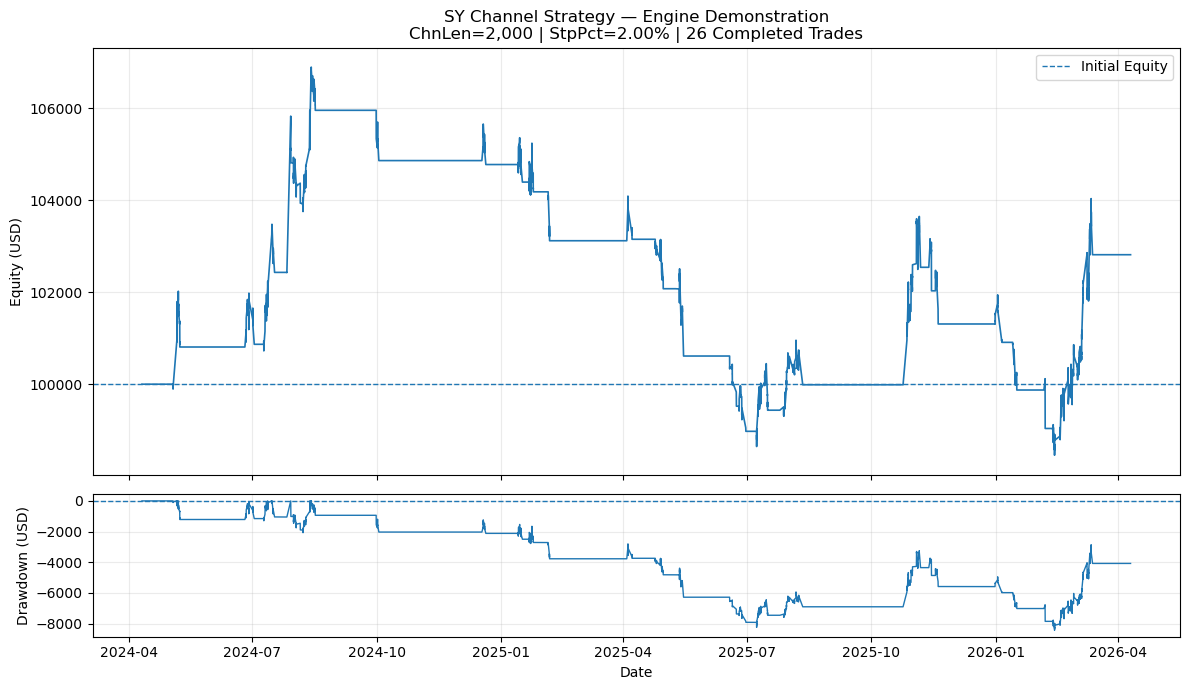

In [15]:
# Evaluation-period equity and drawdown

plot_data = demo_result.copy()

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 7),
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1]}
)

# Equity curve
axes[0].plot(
    plot_data['ts'],
    plot_data['equity'],
    linewidth=1.2
)

axes[0].axhline(
    INITIAL_EQUITY,
    linestyle='--',
    linewidth=1,
    label='Initial Equity'
)

axes[0].set_title(
    f'SY Channel Strategy — Engine Demonstration\n'
    f'ChnLen={CHN_LEN:,} | StpPct={STP_PCT:.2%} | '
    f'{len(trade_ledger)} Completed Trades'
)

axes[0].set_ylabel('Equity (USD)')
axes[0].legend()
axes[0].grid(alpha=0.25)

# Drawdown
axes[1].plot(
    plot_data['ts'],
    plot_data['drawdown'],
    linewidth=1.0
)

axes[1].axhline(
    0,
    linestyle='--',
    linewidth=1
)

axes[1].set_ylabel('Drawdown (USD)')
axes[1].set_xlabel('Date')
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 8. Strategy Mechanics Visualization

To illustrate the mechanics of the strategy, a representative completed trade is
shown together with the market price and the rolling breakout channel.

The visualization provides a direct check that entries occur at channel breakouts
and that subsequent position management is consistent with the implemented
trading rules. It complements the accounting-based validation above by showing
the strategy logic at the individual-trade level.

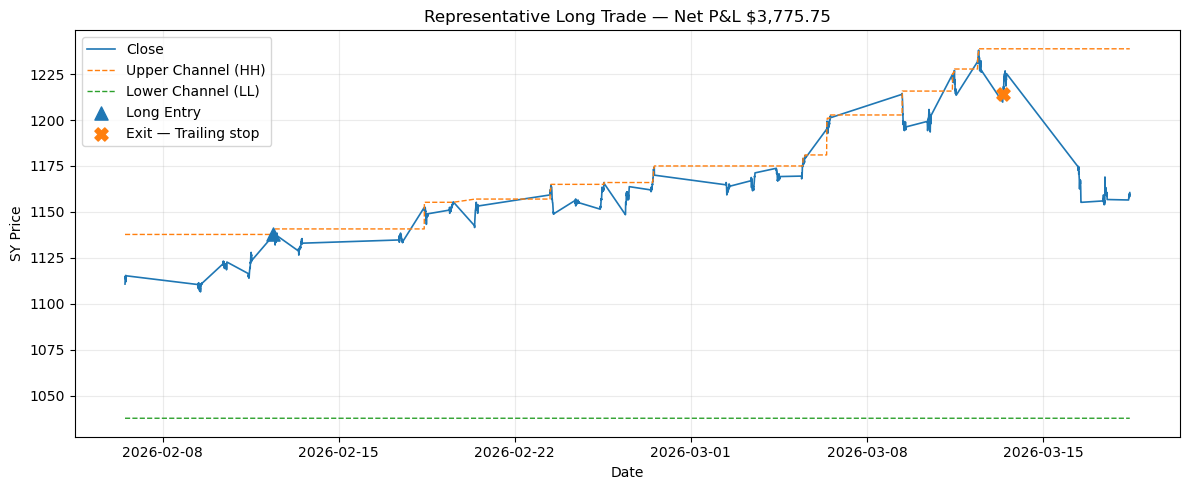

entry_time          2026-02-12 09:35:00
exit_time           2026-03-13 09:35:00
direction                          Long
entry_price                    1,137.75
exit_price                     1,213.97
holding_bars                        900
gross_pnl                      3,811.25
transaction_cost                  35.50
net_pnl                        3,775.75
exit_reason               Trailing stop
Name: 25, dtype: object

In [16]:
# Representative trade and channel visualization

# Select the completed trade with the largest absolute net P&L
example_trade = (
    trade_ledger
    .loc[trade_ledger['net_pnl'].abs().idxmax()]
)

entry_time = example_trade['entry_time']
exit_time = example_trade['exit_time']

# Add context before and after the trade
entry_idx = result.index[result['ts'] == entry_time][0]
exit_idx = result.index[result['ts'] == exit_time][0]

context_bars = 150

start_idx = max(
    0,
    entry_idx - context_bars
)

end_idx = min(
    len(result) - 1,
    exit_idx + context_bars
)

trade_window = (
    result.iloc[start_idx:end_idx + 1]
          .copy()
)

fig, ax = plt.subplots(figsize=(12, 5))

# Market price
ax.plot(
    trade_window['ts'],
    trade_window['Close'],
    linewidth=1.2,
    label='Close'
)

# Breakout channels
ax.plot(
    trade_window['ts'],
    trade_window['HH'],
    linestyle='--',
    linewidth=1.0,
    label='Upper Channel (HH)'
)

ax.plot(
    trade_window['ts'],
    trade_window['LL'],
    linestyle='--',
    linewidth=1.0,
    label='Lower Channel (LL)'
)

# Entry
ax.scatter(
    entry_time,
    example_trade['entry_price'],
    marker='^',
    s=90,
    zorder=5,
    label=f'{example_trade["direction"]} Entry'
)

# Exit
ax.scatter(
    exit_time,
    example_trade['exit_price'],
    marker='X',
    s=90,
    zorder=5,
    label=f'Exit — {example_trade["exit_reason"]}'
)

ax.set_title(
    f'Representative {example_trade["direction"]} Trade — '
    f'Net P&L ${example_trade["net_pnl"]:,.2f}'
)

ax.set_xlabel('Date')
ax.set_ylabel('SY Price')

ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

example_trade

## 9. Conclusion

The implementation checks confirm that the Channel WithDDControl strategy is
internally consistent: breakout channels use only prior information, no trades
occur during the warm-up period, equity and drawdown accounting reconcile
exactly, and the round-trip trade ledger reproduces the strategy P&L.

The fixed parameters used in this notebook are illustrative rather than optimized.
The next stage therefore focuses on walk-forward parameter selection and genuine
out-of-sample evaluation.